In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
dataset_path = "/content/drive/MyDrive/Colab Notebooks/diabetes.csv"

In [16]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [17]:
!find /content/drive/MyDrive -name "*.csv"

/content/drive/MyDrive/Colab Notebooks/diabetes.csv
/content/drive/MyDrive/SLOPE_2025/data (1).csv
/content/drive/MyDrive/SLOPE_2025/data.csv
/content/drive/MyDrive/SLOPE_2025/dataset.csv
/content/drive/MyDrive/DL/Churn_Modelling.csv


In [19]:
# Load dataset
df = pd.read_csv(dataset_path)

In [18]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [20]:
df.info()

df.shape

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [21]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [22]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    print(col, (df[col]==0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [23]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


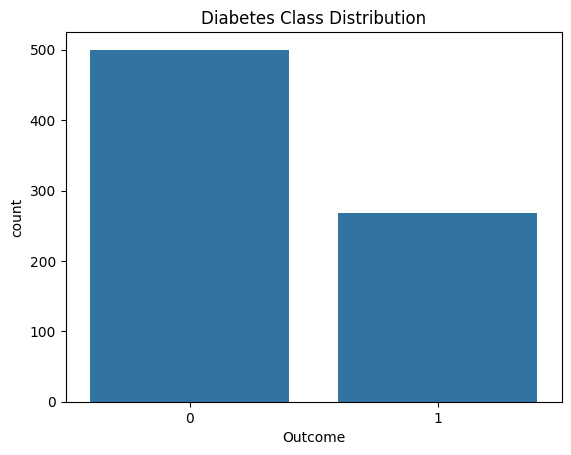

In [24]:
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Class Distribution')
plt.show()

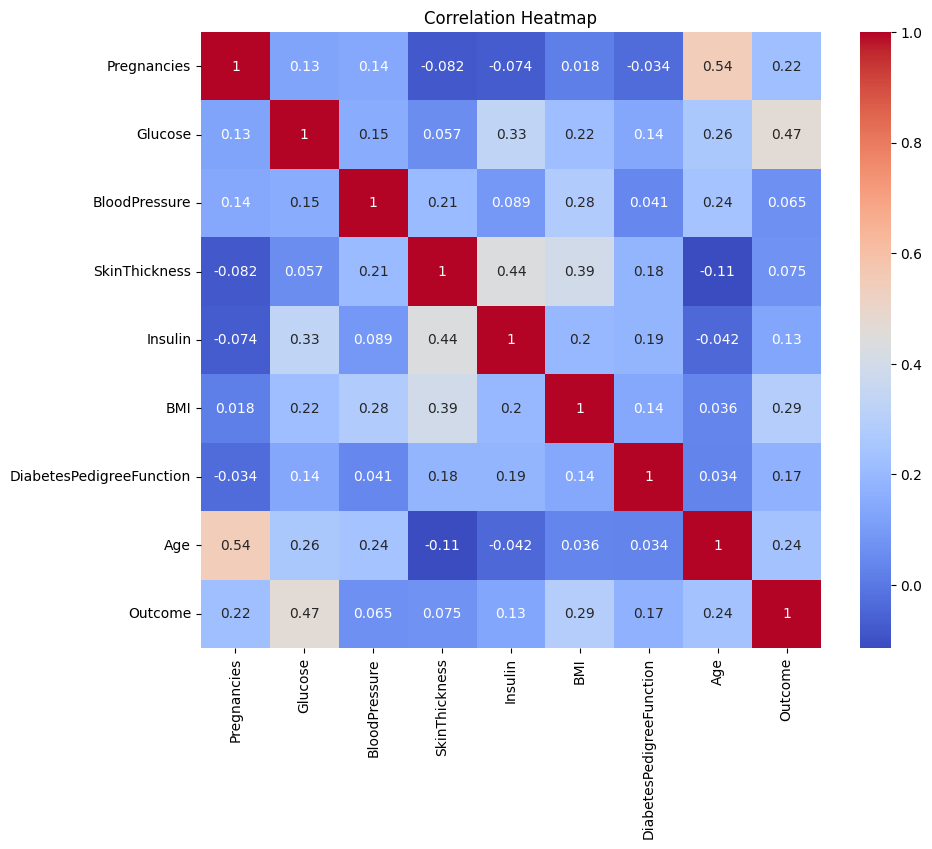

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

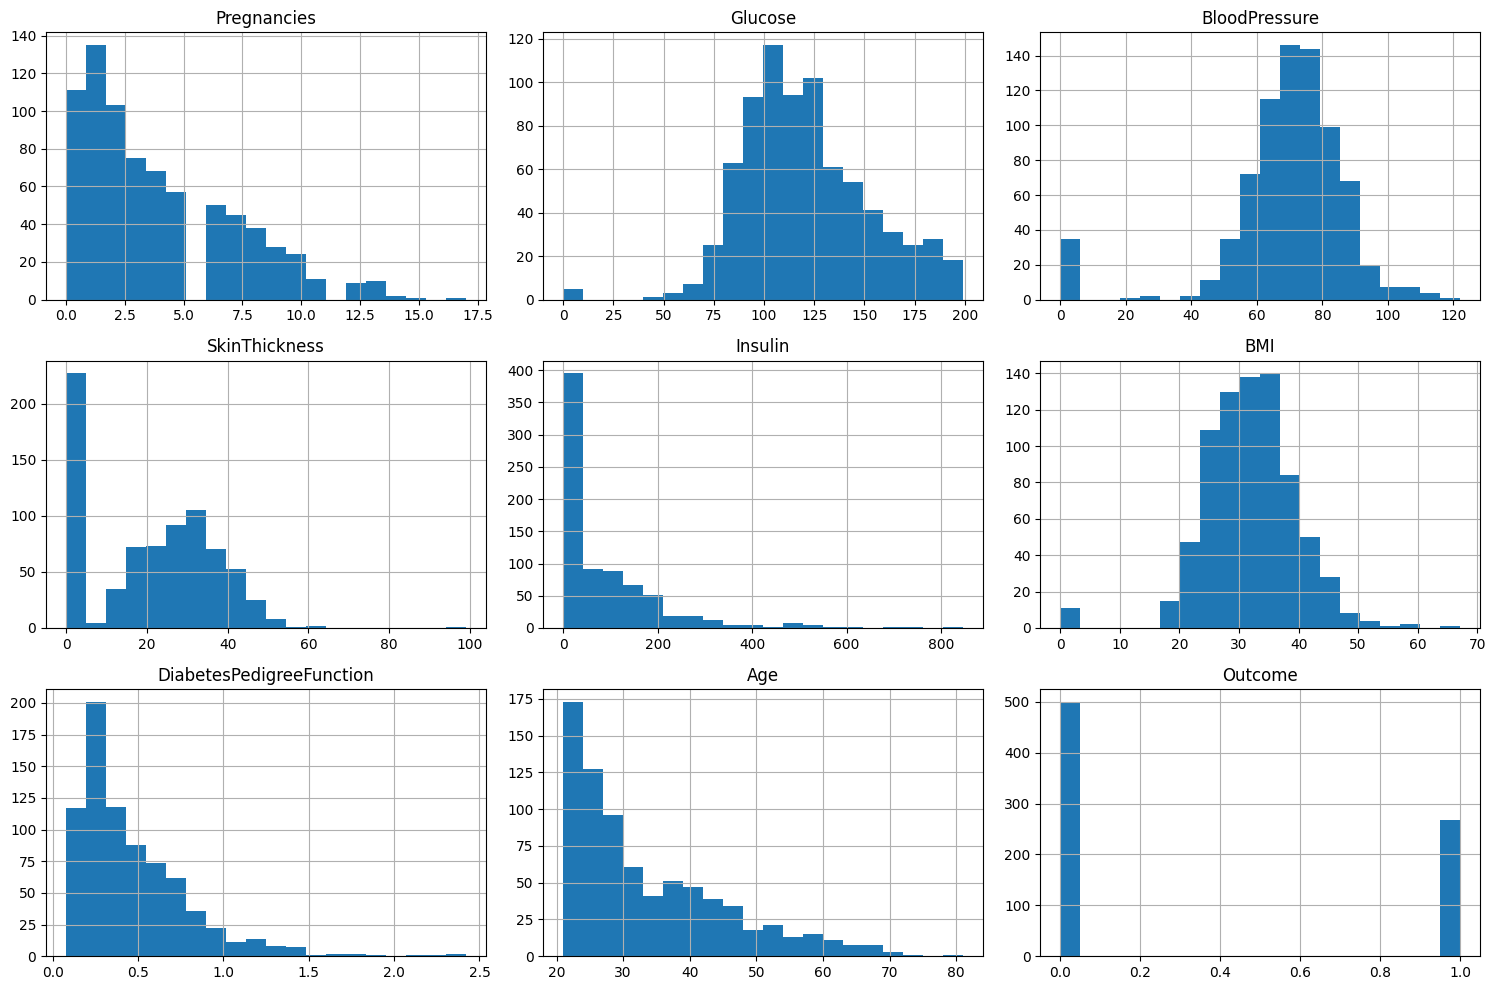

In [26]:
df.hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

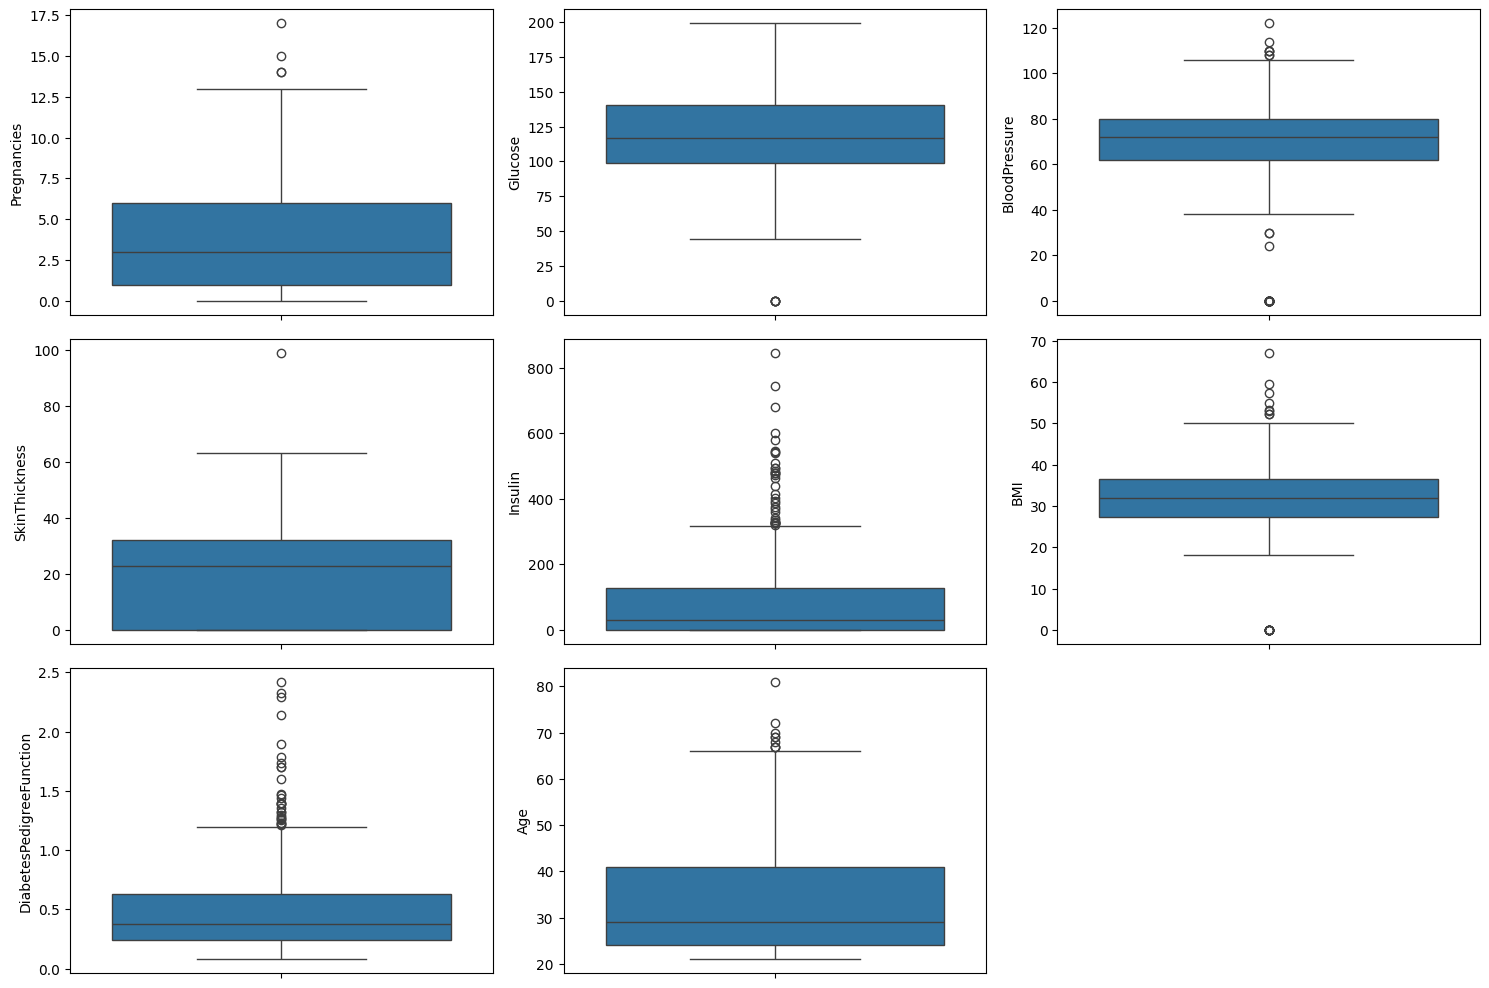

In [27]:
plt.figure(figsize=(15,10))

for i,col in enumerate(df.columns[:-1],1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

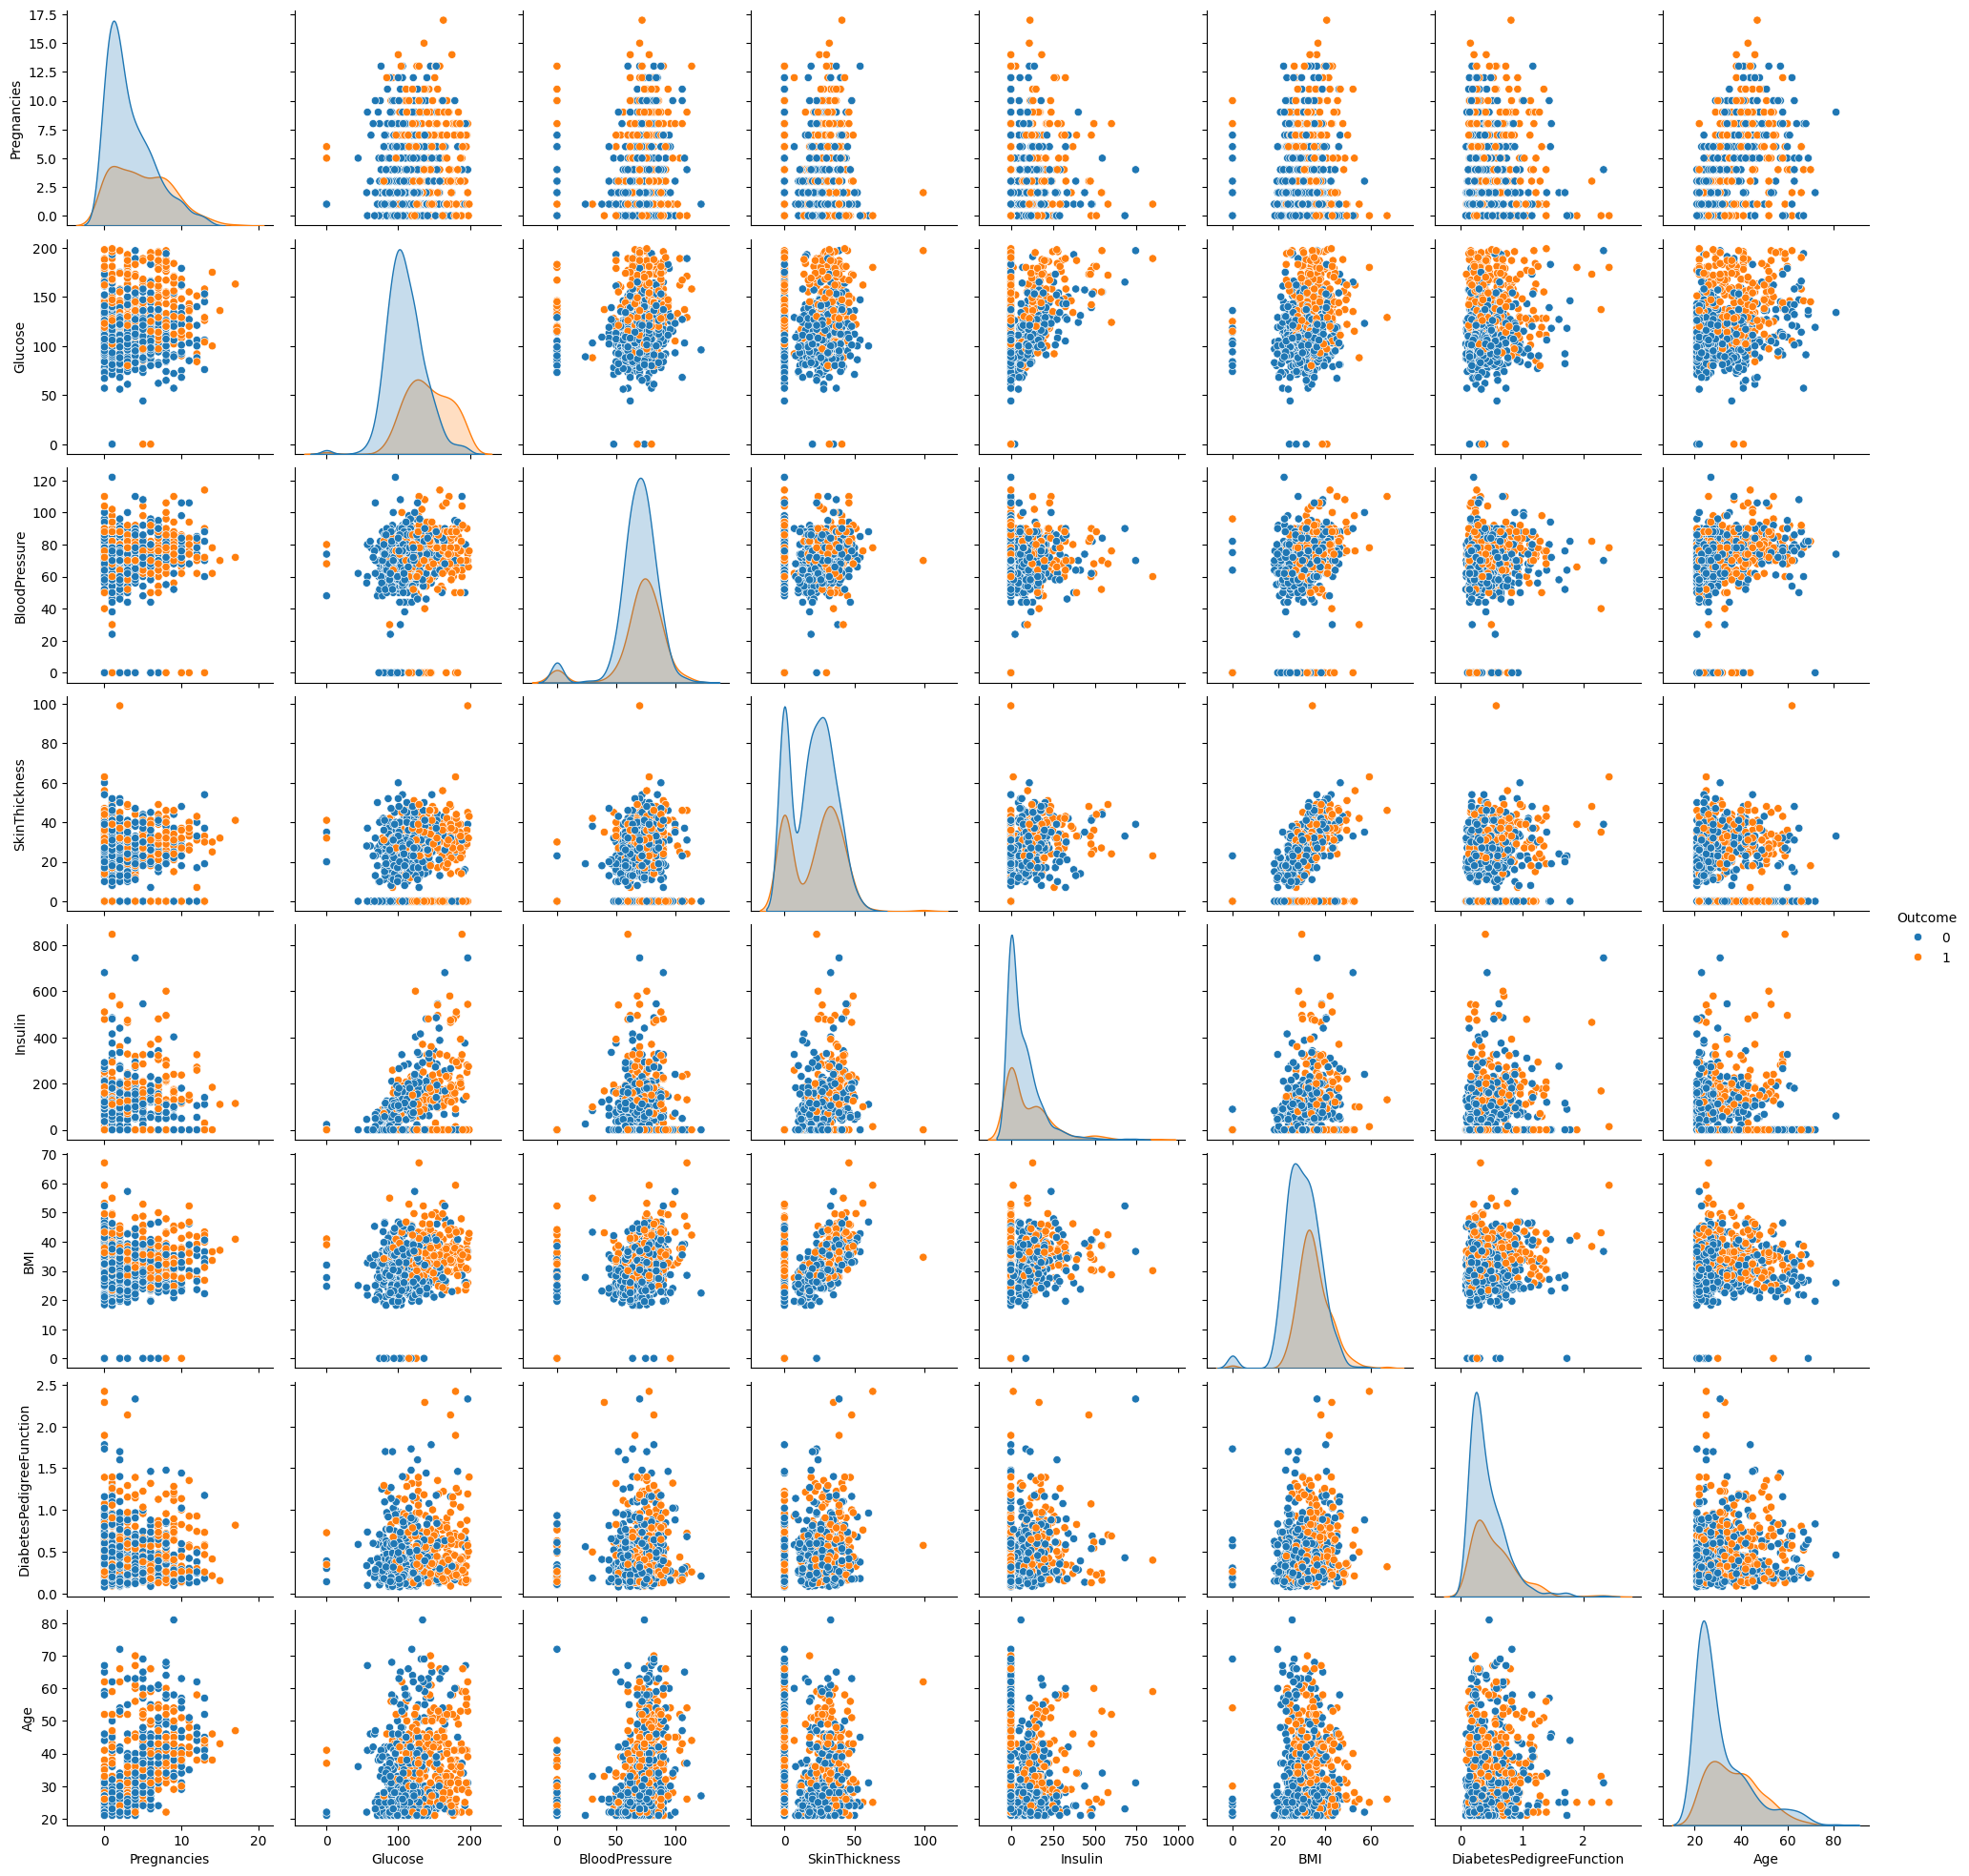

In [29]:
sns.pairplot(
    df,
    hue='Outcome'
)

plt.show()

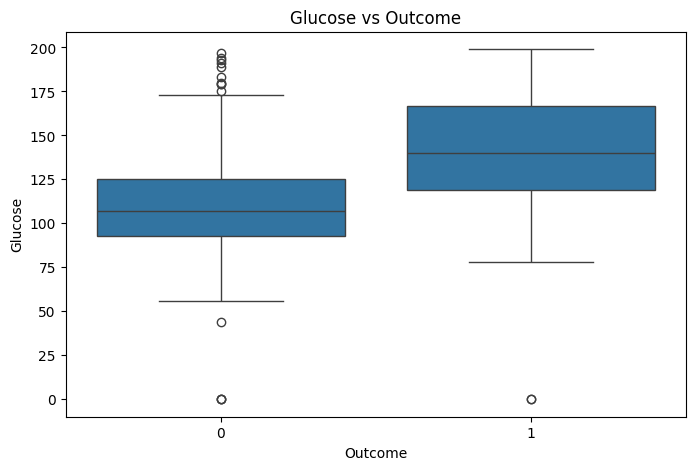

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Outcome',
    y='Glucose',
    data=df
)

plt.title('Glucose vs Outcome')
plt.show()

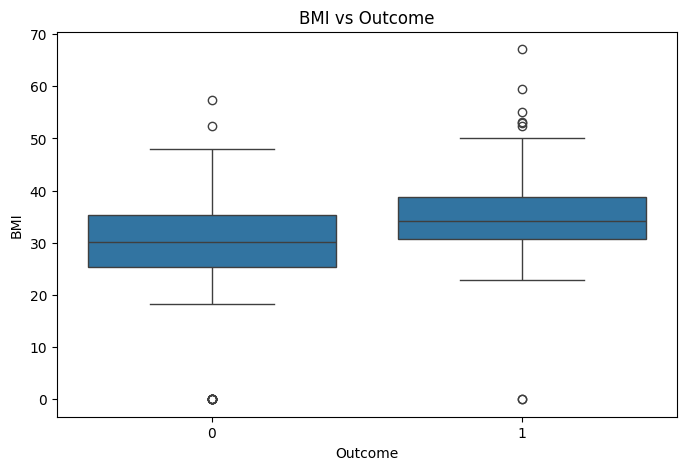

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Outcome',
    y='BMI',
    data=df
)

plt.title('BMI vs Outcome')
plt.show()

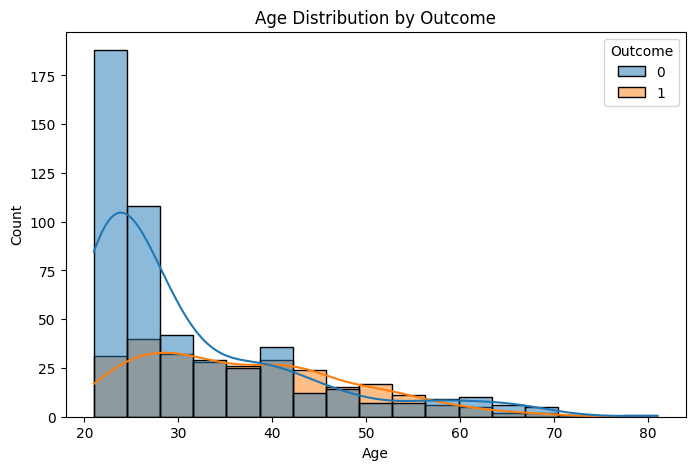

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    hue='Outcome',
    kde=True
)

plt.title('Age Distribution by Outcome')
plt.show()

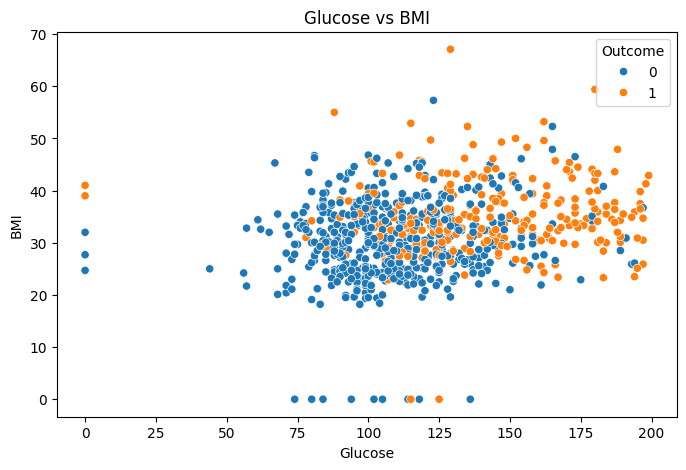

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Glucose',
    y='BMI',
    hue='Outcome',
    data=df
)

plt.title('Glucose vs BMI')
plt.show()

In [33]:
corr_target = df.corr()['Outcome'].sort_values(ascending=False)

print(corr_target)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [34]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_910/3492169658.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [35]:
df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [36]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        1,
        activation='sigmoid',
        input_shape=(X_train.shape[1],)
    )
])

In [40]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [41]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.6971 - loss: 0.6410
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6922 - loss: 0.6335
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6873 - loss: 0.6261
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6954 - loss: 0.6193
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6971 - loss: 0.6127
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7003 - loss: 0.6065
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7020 - loss: 0.6004
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7020 - loss: 0.5952
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7036 - loss: 0.5899
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7020 - loss: 0.5848
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7052 - loss: 0.5795
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7

In [42]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.7338 - loss: 0.5301
Accuracy: 0.7337662577629089


2. Modified Classifier (One Hidden Layer + One Dropout Layer)
In this model:

Hidden Layer = 16 neurons

Activation Function = ReLU

Dropout Layer = 20%

Output Layer = Sigmoid


In [43]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        16,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

In [44]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [45]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 277ms/step - accuracy: 0.6191 - loss: 0.7182 - val_accuracy: 0.6423 - val_loss: 0.6936
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6415 - loss: 0.6883 - val_accuracy: 0.6585 - val_loss: 0.6647
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6640 - loss: 0.6547 - val_accuracy: 0.6829 - val_loss: 0.6403
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6701 - loss: 0.6375 - val_accuracy: 0.6748 - val_loss: 0.6175
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6843 - loss: 0.6214 - val_accuracy: 0.6829 - val_loss: 0.5983
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6823 - loss: 0.6024 - val_accuracy: 0.6911 - val_loss: 0.5823
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6945 - loss: 0.5860 - val_accuracy: 0.6911 - val_loss: 0.5672
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6986 - loss: 0.5747 - val_accuracy: 0.6911 - 

In [47]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7532 - loss: 0.4994 
Accuracy: 0.7532467246055603
